In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])  # XOR outputs 1 only when inputs differ


In [4]:
perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perceptron.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [5]:
y_pred = perceptron.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Perceptron XOR Prediction Accuracy: {accuracy * 100:.1f}%")
print(f"Predicted outputs: {y_pred} (Expected: [0 1 1 0])")

Perceptron XOR Prediction Accuracy: 50.0%
Predicted outputs: [0 0 0 0] (Expected: [0 1 1 0])


In [6]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

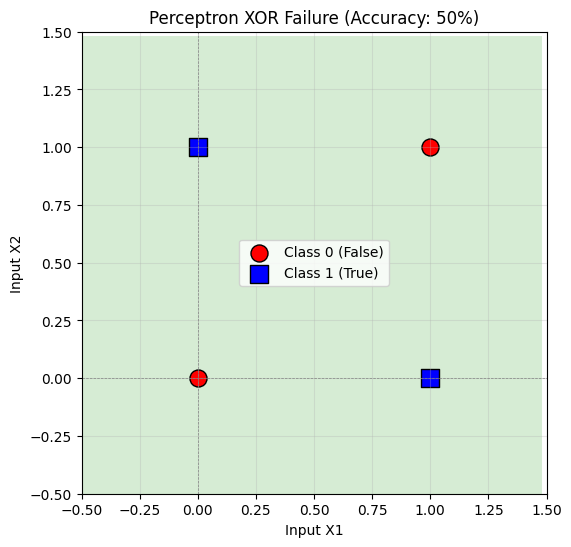

In [11]:
plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.Paired)
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="red",
    marker="o",
    s=150,
    edgecolors="k",
    label="Class 0 (False)",
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="blue",
    marker="s",
    s=150,
    edgecolors="k",
    label="Class 1 (True)",
)
plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title(f"Perceptron XOR Failure (Accuracy: {accuracy * 100:.0f}%)")
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.5, linestyle="--")
plt.legend(loc="center")
plt.grid(True, alpha=0.3)
plt.show()